In [35]:
import numpy as np

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha    = 0.05
c        = 0.5
T        = 0.1

nx_sc    = 100
spawn_per_point = 2
max_candidates  = 1000

n_exact  = 5
box_x0   = 0.15
box_t0   = 0.01
box_xmax = 0.1 / 2
box_tmax = T
box_grow = 1.5

cond_max     = 1e4       # was 1e8 — now meaningful after normalization fix
isotropy_max = 25.0      # max λ_max/λ_min for the neighbor point cloud

dx_ref   = 1.0 / (nx_sc - 1)
dt_sc    = 0.002
min_dist = 0.4 * dx_ref

t_strips = np.arange(0, T + dt_sc, dt_sc)
print(f"dx_ref = {dx_ref:.5f}, dt_sc = {dt_sc:.5f}, strips = {len(t_strips)-1}")


# ─────────────────────────────────────────────
# True solution
# ─────────────────────────────────────────────
def u_true(x, t):
    k = c / (2.0 * alpha)
    def f(p):
        if p == 0:
            return (1.0 - np.exp(-k)) / k if k > 1e-10 else 1.0
        return k * (1.0 - (-1)**p * np.exp(-k)) / (k**2 + (p * np.pi)**2)
    x_arr = np.asarray(x, dtype=float)
    v = np.zeros_like(x_arr)
    for n in range(1, 31):
        v += (f(n-1) - f(n+1)) * np.exp(-alpha*(n*np.pi)**2*t) * np.sin(n*np.pi*x_arr)
    result = np.exp(k*x_arr - k**2*alpha*t) * v
    return float(result) if np.ndim(x) == 0 else result


# ─────────────────────────────────────────────
# FD reference
# ─────────────────────────────────────────────
def generate_fd_reference(nx=200, dt=1e-4):
    x   = np.linspace(0, 1, nx)
    dx  = x[1] - x[0]
    lam = alpha * dt / dx**2

    if lam > 0.3:
        print(f"Warning: scheme may be unstable (λ = {lam:.3f})")

    nt = int(T / dt) + 1
    U  = np.zeros((nt, nx))
    U[0] = u_true(x, 0)

    for k in range(nt - 1):
        U[k+1, 2:-2] = (
            U[k, 2:-2]
            + lam / 12 * (
                -U[k, 4:]
                + 16*U[k, 3:-1]
                - 30*U[k, 2:-2]
                + 16*U[k, 1:-3]
                - U[k, :-4]
            )
            - c*dt / (2*dx) * (U[k, 3:-1] - U[k, 1:-3])
        )
        U[k+1, 1]  = U[k, 1]  + lam*(U[k, 2]  - 2*U[k, 1]  + U[k, 0])  - c*dt/(2*dx)*(U[k, 2]  - U[k, 0])
        U[k+1, -2] = U[k, -2] + lam*(U[k, -1] - 2*U[k, -2] + U[k, -3]) - c*dt/(2*dx)*(U[k, -1] - U[k, -3])
        U[k+1, 0]  = 0.0
        U[k+1, -1] = 0.0

    return x, np.arange(nt) * dt, U


print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference()


def fd_interp(xq, tq):
    ix = np.clip(np.searchsorted(x_fd, xq) - 1, 0, len(x_fd) - 2)
    it = np.clip(np.searchsorted(t_fd, tq) - 1, 0, len(t_fd) - 2)
    tx = (xq - x_fd[ix]) / (x_fd[ix+1] - x_fd[ix])
    tt = (tq - t_fd[it]) / (t_fd[it+1] - t_fd[it])
    return (
        (1-tt)*(1-tx)*U_fd[it,   ix]
      + (1-tt)*tx    *U_fd[it,   ix+1]
      +    tt *(1-tx)*U_fd[it+1, ix]
      +    tt *tx    *U_fd[it+1, ix+1]
    )

#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# ─────────────────────────────────────────────
# Stencil quality — geometry check (before solve)
# ─────────────────────────────────────────────
def stencil_is_good(dx_i, dt_i):
    # 1. Two-sided spatial coverage
    if np.min(dx_i) * np.max(dx_i) > 0:
        return False

    # 2. Minimum spatial span
    if np.max(dx_i) - np.min(dx_i) < 0.9 * dx_ref:
        return False

    # 3. Eigenvalue ratio of point cloud — catches collinearity in (x,t) space
    #    Normalize first so x and t contribute on equal footing
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    pts  = np.column_stack([dx_i / h, dt_i / tau])   # (n, 2)
    C    = pts.T @ pts                                 # 2×2 scatter matrix
    eigs = np.linalg.eigvalsh(C)                       # sorted ascending

    if eigs[0] < 1e-14:                                # numerically flat cloud
        return False
    if eigs[1] / eigs[0] > isotropy_max:               # too elongated / collinear
        return False

    return True


# ─────────────────────────────────────────────
# Weight solver — normalized A + pseudoinverse (SVD)
# ─────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    # Rows normalized to O(1) — fixes the artificial condition number inflation
    A = np.array([
        np.ones(len(dx_i)),
        (dx_i - c*dt_i)                                        / h,
        (0.5*dx_i**2 + alpha*dt_i)                             / h**2
    ])  # shape (4, n)
    b = np.array([1.0, 0.0, 0.0])

    # cond(A) now reflects geometry, not units
    cond = np.linalg.cond(A)
    if cond > cond_max:
        return None, cond

    # Pseudoinverse via SVD — minimum Euclidean norm solution
    w = np.linalg.lstsq(A, b, rcond=None)[0]
    return w, cond

def solve_weights_rbf(dx_i, dt_i):
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    dx_n = dx_i / h
    dt_n = dt_i / tau

    n = len(dx_i)

    r_ij = np.sqrt(
        (dx_n[:, None] - dx_n[None, :])**2 +
        (dt_n[:, None] - dt_n[None, :])**2
    )
    r_star = np.sqrt(dx_n**2 + dt_n**2)

    # Multiquadric with auto epsilon
    eps      = 1.0 / (np.mean(r_ij[r_ij > 0]) + 1e-12)
    phi      = lambda r: np.sqrt(1.0 + (eps * r)**2)
    Phi      = phi(r_ij)
    phi_star = phi(r_star)

    cond = np.linalg.cond(Phi)
    if cond > 1e8:          # relaxed — RBF needs more room than GFDM
        return None, cond

    try:
        w = np.linalg.solve(Phi, phi_star)
    except np.linalg.LinAlgError:
        return None, cond

    return w, cond


def summarise(point_data, visited, label='GFDM'):
    if len(point_data) == 0:
        print(f"[{label}] No points solved — all stencils failed.")
        return None

    print(
        f"[{label}] Done. {len(point_data)} points,  "
        f"mean err = {np.mean([p['err'] for p in point_data]):.3e},  "
        f"max err  = {np.max([p['err'] for p in point_data]):.3e}"
    )

    px        = np.array([p['x']    for p in point_data])
    pt        = np.array([p['t']    for p in point_data])
    pu        = np.array([p['u']    for p in point_data])
    perr      = np.array([p['err']  for p in point_data])
    cond_vals = np.array([p['cond'] for p in point_data])
    w1_vals   = np.array([p['w1']   for p in point_data])
    true_vals = np.array([u_true(p['x'], p['t']) for p in point_data])

    tol_bc = 1e-12
    bc_x = np.array([p[0] for p in visited if abs(p[0]) < tol_bc or abs(p[0]-1) < tol_bc])
    bc_t = np.array([p[1] for p in visited if abs(p[0]) < tol_bc or abs(p[0]-1) < tol_bc])
    ic_x = np.linspace(0, 1, nx_sc)
    ic_t = np.zeros(len(ic_x))

    return dict(
        label=label,
        px=px, pt=pt, pu=pu, perr=perr,
        cond_vals=cond_vals, w1_vals=w1_vals,
        true_vals=true_vals,
        bc_x=bc_x, bc_t=bc_t,
        ic_x=ic_x, ic_t=ic_t,
    )  
# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def far_from_existing(xc, tc, visited):
    for x, t, _ in visited:
        if abs(x - xc) < min_dist and abs(t - tc) < dt_sc * 0.5:
            return False
    return True


def spawn_candidates(xi, ti):
    new = []
    for _ in range(spawn_per_point):
        xc = xi + np.random.uniform(-box_x0, box_x0)
        tc = ti + np.random.uniform(0, box_t0)
        if 0.0 <= xc <= 1.0 and tc <= T:
            new.append((xc, tc))
    return new


def find_neighbours(x_star, t_star, visited):
    bx, bt = box_x0, box_t0
    while True:
        nb = [
            p for p in visited
            if abs(p[0] - x_star) <= bx
            and 0 < (t_star - p[1]) <= bt
        ]
        if len(nb) >= n_exact:
            nb.sort(key=lambda p: (p[0] - x_star)**2 + (p[1] - t_star)**2)
            return nb[:n_exact]
        bx = min(bx * box_grow, box_xmax)
        bt = min(bt * box_grow, box_tmax)
        if bx >= box_xmax and bt >= box_tmax:
            return None


# ─────────────────────────────────────────────
# Main integrator — wrapped for UQ
# ─────────────────────────────────────────────
def run_integrator(seed=None, method='rbf'):
    if seed is not None:
        np.random.seed(seed)

    visited    = []
    point_data = []

    # Initial condition
    for xi in np.linspace(0, 1, nx_sc):
        visited.append((xi, 0.0, u_true(xi, 0.0)))

    # Boundary conditions
    for t in np.arange(0, T + dt_sc, dt_sc):
        visited.append((0.0, t, 0.0))
        visited.append((1.0, t, 0.0))

    # Seed candidates from IC interior points only
    candidates = []
    for xi, ti, _ in visited:
        if abs(xi) < 1e-12 or abs(xi - 1.0) < 1e-12:
            continue
        candidates.extend(spawn_candidates(xi, ti))

    while candidates:
        if len(candidates) > max_candidates:
            candidates = candidates[-max_candidates:]

        idx = np.random.randint(len(candidates))
        x_star, t_star = candidates.pop(idx)

        # Single proximity check (was duplicated in original)
        if not far_from_existing(x_star, t_star, visited):
            continue

        # Boundary points
        if abs(x_star) < 1e-12 or abs(x_star - 1.0) < 1e-12:
            visited.append((x_star, t_star, 0.0))
            continue

        nb = find_neighbours(x_star, t_star, visited)
        if nb is None:
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star

        # Geometry check — eigenvalue ratio + span + two-sided
        if not stencil_is_good(dx_i, dt_i):
            continue

        # Solve — normalized A, cond(A) check, pseudoinverse
        # With this (method flag passed into run_integrator):
        if method == 'rbf':
            w, cond = solve_weights_rbf(dx_i, dt_i)
        else:
            w, cond = solve_weights(dx_i, dt_i)
        if w is None:
            continue

        u_hat = w @ nb_pts[:, 2]
        visited.append((x_star, t_star, u_hat))
        candidates.extend(spawn_candidates(x_star, t_star))

        u_ref = fd_interp(x_star, t_star)
        point_data.append({
            'x':     x_star,
            't':     t_star,
            'u':     u_hat,
            'err':   abs(u_hat - u_ref),
            'w1':    np.sum(np.abs(w)),
            'cond':  cond,
            'nb_x':  nb_pts[:, 0].copy(),
            'nb_t':  nb_pts[:, 1].copy(),
            'nb_u':  nb_pts[:, 2].copy(),
            'box_x': np.max(np.abs(dx_i)),
            'box_t': np.max(np.abs(dt_i)),
        })

    return visited, point_data

visited_gfdm, data_gfdm = run_integrator(seed=42, method='gfdm')
visited_rbf,  data_rbf  = run_integrator(seed=42, method='rbf')

stats_gfdm = summarise(data_gfdm, visited_gfdm, label='GFDM')
stats_rbf  = summarise(data_rbf,  visited_rbf,  label='RBF')

dx_ref = 0.01010, dt_sc = 0.00200, strips = 50
Generating FD reference...
[GFDM] Done. 4012 points,  mean err = 6.232e-03,  max err  = 1.329e-01
[RBF] Done. 4012 points,  mean err = 2.359e+01,  max err  = 7.858e+02


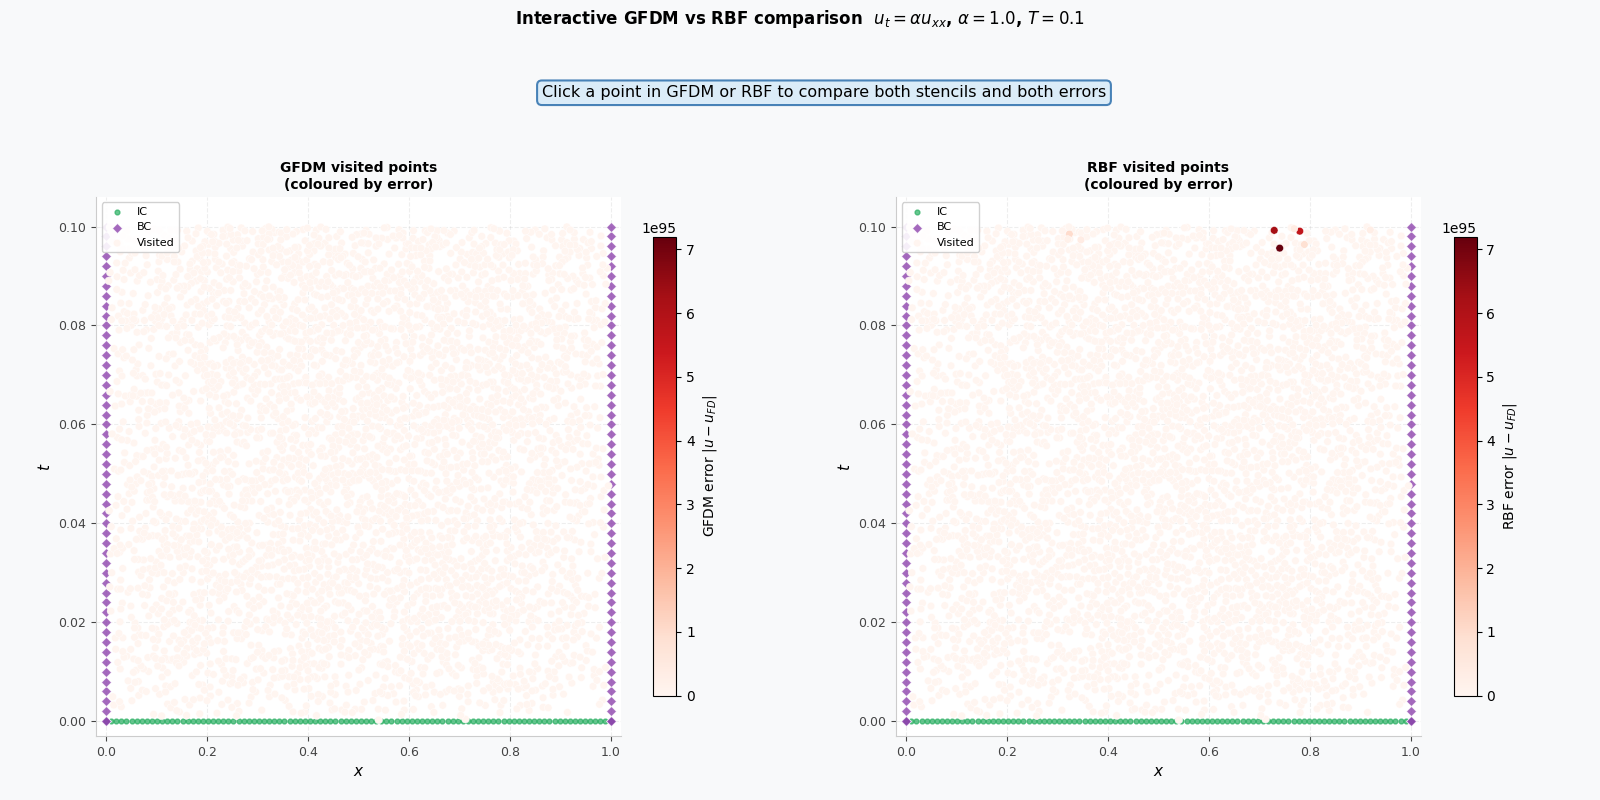

In [34]:
%matplotlib widget

import numpy as np
from Plots.interactive_plot_rbf import interactive_plot_rbf

ic_x = np.linspace(0, 1, nx_sc)
ic_t = np.zeros(len(ic_x))

bc_x = np.array([p[0] for p in visited_rbf if p[0] in [0.0, 1.0]])
bc_t = np.array([p[1] for p in visited_rbf if p[0] in [0.0, 1.0]])

interactive_plot_rbf(
    data_gfdm,
    data_rbf,
    visited_gfdm,
    visited_rbf,
    u_true,
    fd_interp,
    T,
    dt_sc,
    ic_x,
    ic_t,
    bc_x,
    bc_t,
)
